# Global Sensitivity Analysis

Parameter-space exploration showed us that changing model parameters can produce very different predator–prey dynamics.

Because the Wolf–Sheep model is stochastic, the same parameter values can also produce different outcomes across repeated simulations.

In this notebook, we ask:

> **Which parameters have the greatest influence on population peaks and their variability?**

We use **global sensitivity analysis** to quantify the influence of each model parameter.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from SALib import ProblemSpec

from caliagent.models import WolfSheep

## Model Setup

We use the Wolf–Sheep Predation model and run each simulation for 250 timesteps.

For every parameter combination, we repeat the simulation 10 times to account for stochastic variation.

In [17]:
N_STEPS = 250
N_REPLICATES = 10

INITIAL_SHEEP = 150
INITIAL_WOLVES = 5

In [18]:
def simulate(
    sheep_reproduce=0.2,
    wolf_reproduce=0.05,
    wolf_gain_from_food=12,
    grass_regrowth_time=5,
    sheep_gain_from_food=12,
    seed=None,
):
    """Run one Wolf-Sheep simulation and return the population trajectory."""

    model = WolfSheep(
        initial_sheep=INITIAL_SHEEP,
        initial_wolves=INITIAL_WOLVES,
        grass=True,
        sheep_reproduce=sheep_reproduce,
        wolf_reproduce=wolf_reproduce,
        wolf_gain_from_food=wolf_gain_from_food,
        grass_regrowth_time=int(round(grass_regrowth_time)),
        sheep_gain_from_food=sheep_gain_from_food,
        seed=seed,
    )

    sheep = np.empty(N_STEPS + 1)
    wolves = np.empty(N_STEPS + 1)

    sheep[0] = model.sheep_count
    wolves[0] = model.wolf_count

    for step in range(1, N_STEPS + 1):
        model.step()

        sheep[step] = model.sheep_count
        wolves[step] = model.wolf_count

    return pd.DataFrame(
        {
            "step": np.arange(N_STEPS + 1),
            "sheep": sheep,
            "wolves": wolves,
        }
    )

## Predator–Prey Dynamics

The model produces population trajectories for both sheep and wolves.

Rather than analysing the population at a single timestep, we will focus on the **peak population** reached during each simulation.

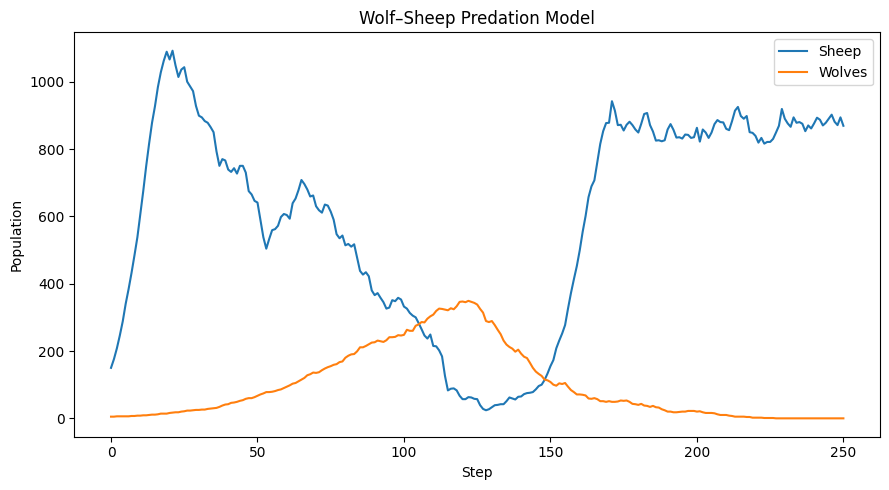

In [19]:
baseline = simulate(seed=1)

plt.figure(figsize=(9, 5))

plt.plot(
    baseline["step"],
    baseline["sheep"],
    label="Sheep",
)

plt.plot(
    baseline["step"],
    baseline["wolves"],
    label="Wolves",
)

plt.xlabel("Step")
plt.ylabel("Population")
plt.title("Wolf–Sheep Predation Model")
plt.legend()
plt.tight_layout()
plt.show()

## What Are We Measuring?

For each simulation, we record:

- the **peak sheep population**;
- the **peak wolf population**.

Because the model is stochastic, repeated simulations with the same parameters may reach different population peaks.

For each parameter combination, we therefore calculate:

- **Mean peak:** the average peak population across replicate simulations.
- **Variance in peak:** how much the peak population varies between replicate simulations.

This allows us to investigate which parameters affect both the **typical magnitude of population peaks** and their **stochastic variability**.

In [20]:
sheep_peaks = []
wolf_peaks = []

for seed in range(N_REPLICATES):
    result = simulate(seed=seed)

    sheep_peaks.append(
        result["sheep"].max()
    )

    wolf_peaks.append(
        result["wolves"].max()
    )

peak_summary = pd.DataFrame({
    "Population": ["Sheep", "Wolves"],
    "Mean Peak": [
        np.mean(sheep_peaks),
        np.mean(wolf_peaks),
    ],
    "Variance in Peak": [
        np.var(sheep_peaks, ddof=1),
        np.var(wolf_peaks, ddof=1),
    ],
})

peak_summary

,Population,Mean Peak,Variance in Peak
0,Sheep,1149.8,4866.844444
1,Wolves,344.6,814.711111


## Define the Parameter Space

We define plausible ranges for each of the five model parameters.

Global sensitivity analysis will explore how variation across these ranges affects population peaks.

In [21]:
problem = {
    "names": [
        "sheep_reproduce",
        "wolf_reproduce",
        "wolf_gain_from_food",
        "grass_regrowth_time",
        "sheep_gain_from_food",
    ],
    "bounds": [
        [0.10, 0.30],
        [0.02, 0.08],
        [8.0, 16.0],
        [2.0, 10.0],
        [8.0, 16.0],
    ],
}

## Generate a Sobol Sampling Design

Sobol sensitivity analysis uses a structured sampling design to explore the parameter space.

This allows us to estimate how much each parameter contributes to variation in the model outputs.

In [32]:
sp = ProblemSpec(problem)

sp.sample_sobol(
    32,
    calc_second_order=False,
)

len(sp.samples)

224

With five parameters and a base sample size of 32, the Sobol design generates:

$$
32 \times (5 + 2) = 224
$$

different parameter combinations.

We run each parameter combination 10 times to account for stochastic variation:

$$
224 \times 10 = 2{,}240
$$

model simulations in total.

## Run the Simulations

For each parameter combination:

1. Run 10 replicate simulations.
2. Find the maximum sheep and wolf population in each replicate.
3. Calculate the mean population peak across replicates.
4. Calculate the variance in population peak across replicates.

Each parameter combination therefore produces four model outputs.

In [23]:
def evaluate(params):
    """Calculate mean and variance of population peaks across replicates."""

    (
        sheep_reproduce,
        wolf_reproduce,
        wolf_gain_from_food,
        grass_regrowth_time,
        sheep_gain_from_food,
    ) = params

    sheep_peaks = np.empty(N_REPLICATES)
    wolf_peaks = np.empty(N_REPLICATES)

    for replicate in range(N_REPLICATES):
        result = simulate(
            sheep_reproduce=sheep_reproduce,
            wolf_reproduce=wolf_reproduce,
            wolf_gain_from_food=wolf_gain_from_food,
            grass_regrowth_time=grass_regrowth_time,
            sheep_gain_from_food=sheep_gain_from_food,
            seed=replicate,
        )

        sheep_peaks[replicate] = (
            result["sheep"].max()
        )

        wolf_peaks[replicate] = (
            result["wolves"].max()
        )

    return {
        "sheep_peak_mean": sheep_peaks.mean(),
        "sheep_peak_variance": sheep_peaks.var(ddof=1),
        "wolf_peak_mean": wolf_peaks.mean(),
        "wolf_peak_variance": wolf_peaks.var(ddof=1),
    }

results = [
    evaluate(params)
    for params in sp.samples
]

results = pd.DataFrame(results)

results.head()

,sheep_peak_mean,sheep_peak_variance,wolf_peak_mean,wolf_peak_variance
0,671.7,1162.900000,200.6,1506.488889
1,713.9,891.433333,224.2,2248.844444
2,671.5,456.944444,160.6,1763.155556
3,660.8,986.844444,219.8,2079.066667
4,672.4,986.711111,191.5,2050.055556


## Calculate Sobol Sensitivity Indices

We perform a separate Sobol analysis for each population summary.

We focus on:

- **First-order sensitivity (S1):** the influence of a parameter on its own.
- **Total-order sensitivity (ST):** its overall influence, including interactions with other parameters.

Larger values indicate greater influence on the population peak or its variability.

In [24]:
def analyze_output(values):
    """Calculate Sobol indices for one model output."""

    analysis = ProblemSpec(problem)

    analysis.samples = sp.samples
    analysis.set_results(
        np.asarray(values)
    )

    analysis.analyze_sobol(
        calc_second_order=False,
        print_to_console=False,
    )

    return pd.DataFrame({
        "Parameter": problem["names"],
        "S1": analysis.analysis["S1"],
        "ST": analysis.analysis["ST"],
    })

sheep_peak_mean_sa = analyze_output(
    results["sheep_peak_mean"]
)

sheep_peak_variance_sa = analyze_output(
    results["sheep_peak_variance"]
)

wolf_peak_mean_sa = analyze_output(
    results["wolf_peak_mean"]
)

wolf_peak_variance_sa = analyze_output(
    results["wolf_peak_variance"]
)

## What Influences the Peak Sheep Population?

We first examine which parameters have the greatest influence on the **average peak sheep population** across replicate simulations.

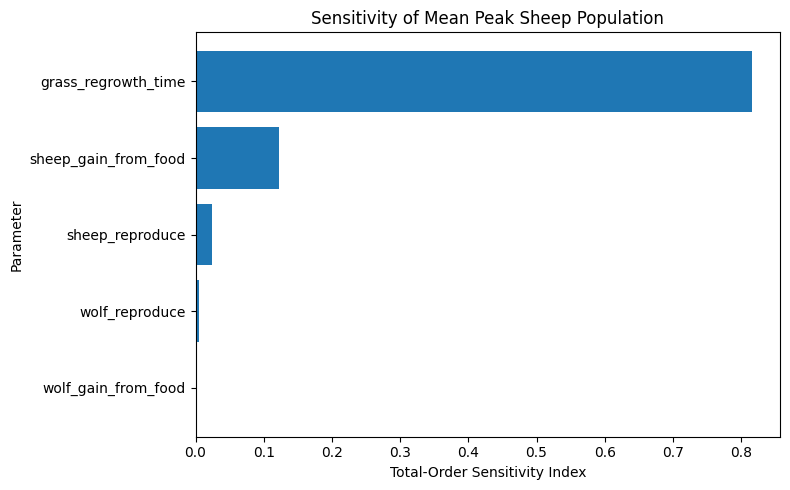

In [26]:
plot_data = (
    sheep_peak_mean_sa
    .sort_values("ST", ascending=False)
)

plt.figure(figsize=(8, 5))

plt.barh(
    plot_data["Parameter"],
    plot_data["ST"],
)

plt.xlabel("Total-Order Sensitivity Index")
plt.ylabel("Parameter")
plt.title(
    "Sensitivity of Mean Peak Sheep Population"
)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## What Influences Variability in the Sheep Peak?

We can also ask which parameters determine how much the **peak sheep population varies between replicate simulations**.

These do not necessarily have to be the same parameters that control the average peak.

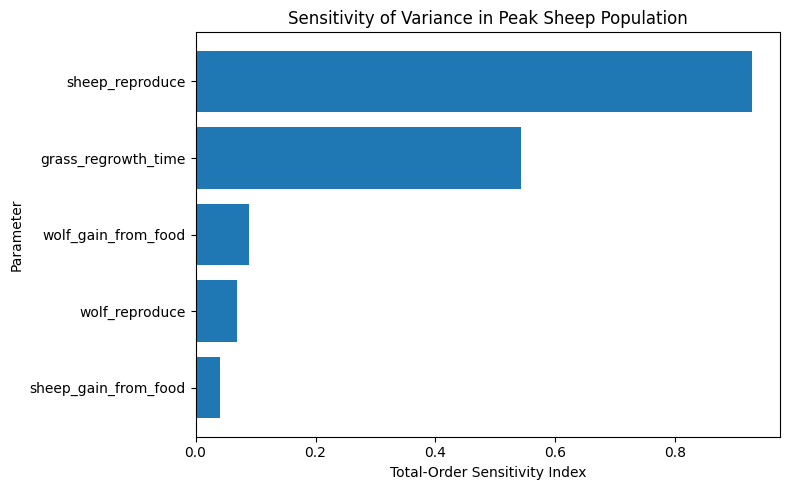

In [27]:
plot_data = (
    sheep_peak_variance_sa
    .sort_values("ST", ascending=False)
)

plt.figure(figsize=(8, 5))

plt.barh(
    plot_data["Parameter"],
    plot_data["ST"],
)

plt.xlabel("Total-Order Sensitivity Index")
plt.ylabel("Parameter")
plt.title(
    "Sensitivity of Variance in Peak Sheep Population"
)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## What Influences the Peak Wolf Population?

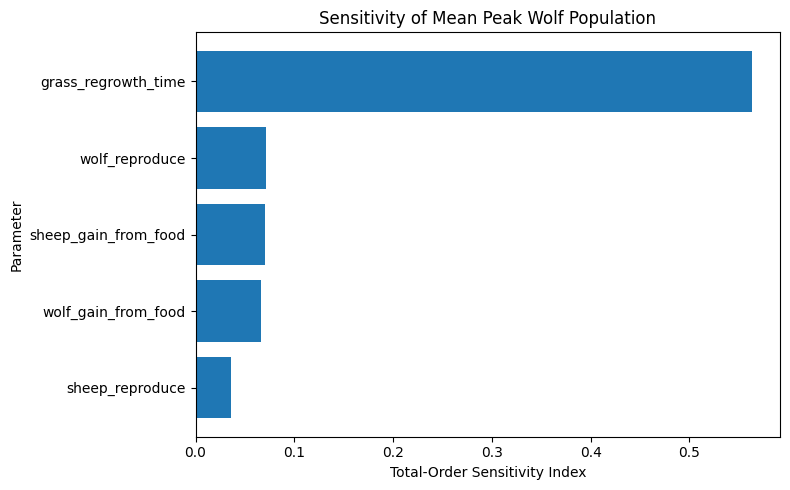

In [28]:
plot_data = (
    wolf_peak_mean_sa
    .sort_values("ST", ascending=False)
)

plt.figure(figsize=(8, 5))

plt.barh(
    plot_data["Parameter"],
    plot_data["ST"],
)

plt.xlabel("Total-Order Sensitivity Index")
plt.ylabel("Parameter")
plt.title(
    "Sensitivity of Mean Peak Wolf Population"
)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## What Influences Variability in the Wolf Peak?

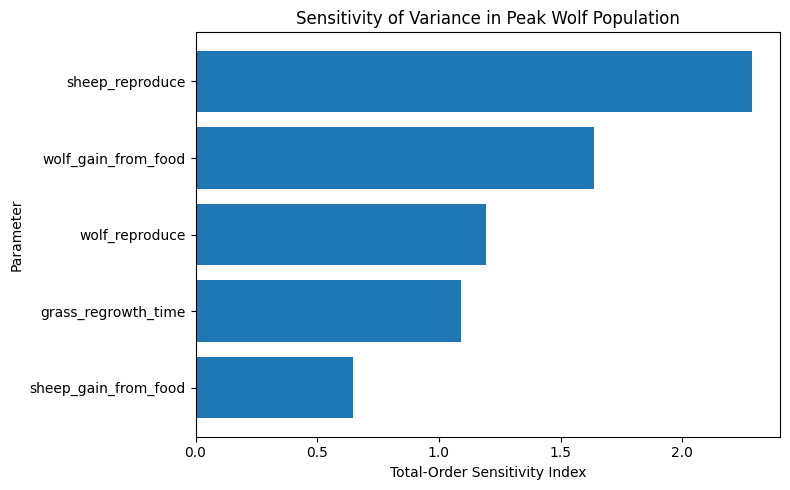

In [29]:
plot_data = (
    wolf_peak_variance_sa
    .sort_values("ST", ascending=False)
)

plt.figure(figsize=(8, 5))

plt.barh(
    plot_data["Parameter"],
    plot_data["ST"],
)

plt.xlabel("Total-Order Sensitivity Index")
plt.ylabel("Parameter")
plt.title(
    "Sensitivity of Variance in Peak Wolf Population"
)

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Comparing Mean Behaviour and Variability

Parameters can affect different aspects of the predator–prey dynamics.

A parameter might strongly influence the **average population peak** but have relatively little influence on how variable that peak is between simulations.

Alternatively, a parameter may primarily affect the **stochastic variability** of the model.

In [30]:
sensitivity_summary = pd.DataFrame({
    "Parameter": problem["names"],
    "Sheep Peak Mean": sheep_peak_mean_sa["ST"],
    "Sheep Peak Variance": sheep_peak_variance_sa["ST"],
    "Wolf Peak Mean": wolf_peak_mean_sa["ST"],
    "Wolf Peak Variance": wolf_peak_variance_sa["ST"],
})

sensitivity_summary

,Parameter,Sheep Peak Mean,Sheep Peak Variance,Wolf Peak Mean,Wolf Peak Variance
0,sheep_reproduce,0.024215,0.927923,0.036395,2.287311
1,wolf_reproduce,0.004952,0.069002,0.071605,1.195111
2,wolf_gain_from_food,0.000735,0.088665,0.066307,1.638143
3,grass_regrowth_time,0.816146,0.541908,0.563450,1.090478
4,sheep_gain_from_food,0.121707,0.040614,0.070506,0.648173


## Do Parameter Interactions Matter?

First-order sensitivity measures the influence of a parameter on its own.

Total-order sensitivity also includes interactions with other parameters.

A large difference between the two suggests that the effect of a parameter depends on the values of other parameters.

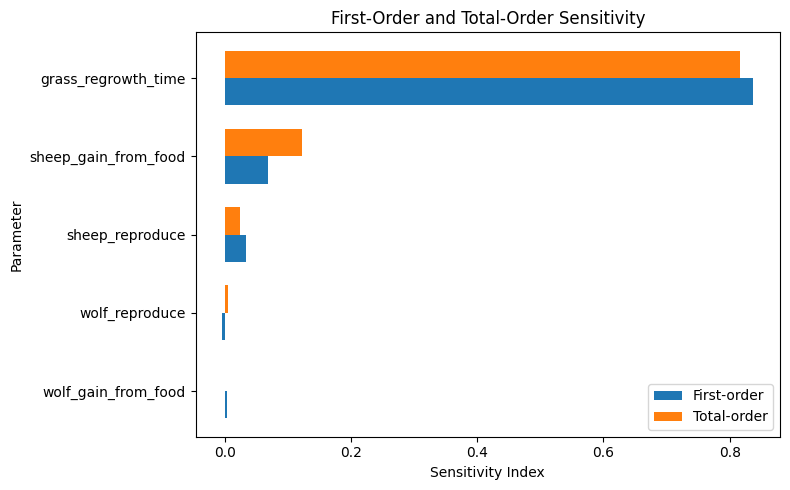

In [31]:
plot_data = (
    sheep_peak_mean_sa
    .sort_values("ST", ascending=True)
)

y = np.arange(len(plot_data))
height = 0.35

plt.figure(figsize=(8, 5))

plt.barh(
    y - height / 2,
    plot_data["S1"],
    height=height,
    label="First-order",
)

plt.barh(
    y + height / 2,
    plot_data["ST"],
    height=height,
    label="Total-order",
)

plt.yticks(
    y,
    plot_data["Parameter"],
)

plt.xlabel("Sensitivity Index")
plt.ylabel("Parameter")
plt.title(
    "First-Order and Total-Order Sensitivity"
)

plt.legend()
plt.tight_layout()
plt.show()

## Interpreting the Results

The sensitivity analysis tells us which parameters influence different aspects of predator–prey behaviour.

### Mean population peak

Sensitivity of the mean peak tells us which parameters control **how large the population typically becomes**.

### Variance in population peak

Sensitivity of the variance tells us which parameters control **how much the peak differs between repeated simulations**.

These may be different parameters.

This distinction is particularly important for stochastic models, where parameters can influence both the expected behaviour of the system and the variability around that behaviour.

## What Does This Mean for Calibration?

Sensitivity analysis can help us decide which parameters deserve attention during calibration.

Parameters that strongly influence the observed model behaviour may be particularly important to calibrate.

However:

- **Sensitivity** asks whether changing a parameter changes the model output.
- **Identifiability** asks whether the observations contain enough information to determine that parameter.

A parameter can be highly sensitive but still poorly identifiable if changes in other parameters can compensate for it.

For stochastic models, we may also need to decide whether calibration should reproduce the **average behaviour**, the **variability between simulations**, or both.

## What Have We Learned?

In this notebook, we used global sensitivity analysis to investigate population peaks in the Wolf–Sheep model.

We found that:

- different parameters can influence sheep and wolf population peaks differently;
- parameters can affect the **mean population peak** and its **variability across replicate simulations** differently;
- total-order sensitivity captures both direct effects and parameter interactions; and
- sensitivity analysis can help identify which parameters and model behaviours deserve further attention during calibration.

> **Sensitivity analysis helps us understand which parameters control different aspects of model behaviour.**